# 27. GMRES and Nonsymmetric Solvers

**Part 4: Iterative and Krylov Subspace Methods**

## Learning objectives

By the end of this lesson you will be able to:

1. Derive **GMRES** as a least squares problem over the Krylov space, and solve it with
   **Givens rotations** in $O(m)$ work per step.
2. Explain why GMRES's residual is **monotone** and available **before the iterate is formed**.
3. Measure what **restarting** costs, and exhibit a problem where it stagnates completely.
4. State and demonstrate that **eigenvalues do not determine GMRES convergence** for a
   nonsymmetric matrix.
5. Use the **field of values** as the substitute that survives non-normality, and say where it
   is vacuous.
6. Explain how **biorthogonality** buys back a short recurrence, and what it costs.
7. Recognise and trigger **BiCG breakdown**, and see why a relative test is needed to detect it.
8. Choose between GMRES, restarted GMRES, BiCG and BiCGSTAB on measured evidence.
9. Place **MINRES** correctly: symmetry without definiteness.

## Prerequisites

Lesson 26 (Arnoldi, and why symmetry gives a short recurrence). Lesson 24 (CG, optimality over
a Krylov space). Lesson 16 (orthogonal projectors). Lesson 06 (conditioning against stability).
Lesson 40 (pseudospectra) is referred to forwards.

---

## 1. What symmetry was paying for

Lesson 26 established the chain. Symmetry makes $H_m = Q_m^TAQ_m$ symmetric; a symmetric upper
Hessenberg matrix is **tridiagonal**; a tridiagonal $H$ means a new Krylov vector needs
orthogonalizing against only the previous two. That is the entire reason CG stores three
vectors instead of $m$.

Drop symmetry and every link breaks at once. $H_m$ is Hessenberg and nothing more, column $j$
has $j+1$ nonzeros, and the new vector must be orthogonalized against **all** its predecessors.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import nonsymmetric as nsym, krylov as kr

sizes = [10, 50, 100, 500, 1000]
big_n = 10**6

print("what one step costs, at n =", f"{big_n:,}")
print(f"{'step m':>8} {'CG vectors':>12} {'GMRES vectors':>15} "
      f"{'CG flops':>12} {'GMRES flops':>14}")
for m in sizes:
    print(f"{m:>8} {3:>12} {m + 1:>15} {5 * big_n:>12,} {(2 * m + 3) * big_n:>14,}")

held = (sizes[-1] + 1) * big_n * 8 / 1e9
print()
print(f"at m = {sizes[-1]}, GMRES is holding {held:.1f} GB of basis vectors")
print("CG is holding 24 MB, at every m, forever.")

what one step costs, at n = 1,000,000
  step m   CG vectors   GMRES vectors     CG flops    GMRES flops
      10            3              11    5,000,000     23,000,000
      50            3              51    5,000,000    103,000,000
     100            3             101    5,000,000    203,000,000
     500            3             501    5,000,000  1,003,000,000
    1000            3            1001    5,000,000  2,003,000,000

at m = 1000, GMRES is holding 8.0 GB of basis vectors
CG is holding 24 MB, at every m, forever.


**Both the storage and the work per step grow linearly with the step count.** After $m$ steps
GMRES has done $O(m^2n)$ orthogonalization work, against CG's $O(mn)$.

That leaves exactly two escapes, and this lesson takes both.

**Keep the orthogonality and pay.** GMRES stores everything and is optimal. Restarting bounds
the cost and gives up the optimality.

**Keep the short recurrence and give up the orthogonality.** BiCG makes two sequences
**biorthogonal** instead of one sequence orthogonal, which restores a three-term recurrence,
and pays with a residual that can grow by orders of magnitude and a breakdown with no analogue
in CG.

---

## 2. GMRES as a least squares problem

At step $m$ the iterate is $\mathbf{x}_0 + Q_m\mathbf{y}$ for some $\mathbf{y} \in
\mathbb{R}^m$. Substituting the Arnoldi relation $AQ_m = Q_{m+1}\tilde{H}_m$:

$$\mathbf{b} - A(\mathbf{x}_0 + Q_m\mathbf{y}) = \mathbf{r}_0 - Q_{m+1}\tilde{H}_m\mathbf{y}
= Q_{m+1}\left(\beta\mathbf{e}_1 - \tilde{H}_m\mathbf{y}\right),$$

using $\mathbf{r}_0 = \beta\mathbf{q}_1 = \beta Q_{m+1}\mathbf{e}_1$. Since $Q_{m+1}$ has
orthonormal columns it preserves the 2-norm (lesson 16), so

> **Proposition 27.1.** Minimising $\|\mathbf{b} - A\mathbf{x}\|_2$ over
> $\mathbf{x}_0 + K_m$ is exactly the $(m{+}1) \times m$ least squares problem
> $$\min_{\mathbf{y}} \left\|\beta\mathbf{e}_1 - \tilde{H}_m\mathbf{y}\right\|_2.$$

**The large problem has become a small one**, and the reduction was free: it is the Arnoldi
relation and the norm-preserving property of $Q$, nothing else.

Two consequences follow immediately and neither has any counterpart in BiCG.

> **Proposition 27.2.** GMRES's residual norm is **non-increasing**.

because $K_m \subseteq K_{m+1}$, so the minimum over the larger set cannot be larger.

> **Proposition 27.3.** GMRES is **optimal** in the residual 2-norm among all methods whose
> $m$-th iterate lies in $\mathbf{x}_0 + K_m$.

which by lesson 26 exercise 5.2 is every method using $m$ matrix-vector products.

---

## 3. Givens rotations, and a free residual

Solving the least squares problem from scratch at every step would cost $O(m^3)$. It is
Hessenberg, so it can be **updated**: each new column adds one subdiagonal entry, and one
Givens rotation removes it. The previous rotations are replayed, which is $O(m)$ work.

A Givens rotation must be computed carefully. The obvious formula
$c = a/\sqrt{a^2+b^2}$ overflows above $1.3\times10^{154}$ and underflows to $0/0$ below
$10^{-162}$, and scaling by the larger of the two first removes both failures at the cost of
one comparison.

In [3]:
import numpy as np

print("the naive rotation against the scaled one\n")
print(f"{'a':>12} {'b':>12} {'naive c':>14} {'scaled c':>14}")
for a, b in [(3.0, 4.0), (1e200, 1e200), (1e-200, 1e-200), (1e300, 1.0)]:
    with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
        naive = a / np.sqrt(a * a + b * b)
    c, s = nsym.givens(a, b)
    print(f"{a:>12.0e} {b:>12.0e} {naive:>14.6f} {c:>14.6f}")

print()
print("the naive form fails at both ends of the exponent range.")
print("both failures are the same mistake: forming a^2 before dividing.")
print("this is lesson 05's cancellation problem in its scaling form.")

the naive rotation against the scaled one

           a            b        naive c       scaled c
       3e+00        4e+00       0.600000       0.600000
      1e+200       1e+200       0.000000       0.707107
      1e-200       1e-200            inf       0.707107
      1e+300        1e+00       0.000000       1.000000

the naive form fails at both ends of the exponent range.
both failures are the same mistake: forming a^2 before dividing.
this is lesson 05's cancellation problem in its scaling form.


**And now the property that makes GMRES practical.** After the rotations, the transformed
right-hand side is $(\gamma_1, \dots, \gamma_m, \gamma_{m+1})$ and the least squares residual
is exactly $|\gamma_{m+1}|$. So **the residual norm is known before $\mathbf{y}$ is solved for
and before $\mathbf{x}$ is ever formed**.

In [4]:
rng27 = np.random.default_rng(2027)
n_res = 60
A_res = rng27.standard_normal((n_res, n_res)) + 4.0 * np.eye(n_res)
b_res = rng27.standard_normal(n_res)

run = nsym.gmres(A_res, b_res, tol=1e-13, max_iter=n_res, keep_history=True)
true = np.array([np.linalg.norm(b_res - A_res @ xk) for xk in run.iterates])
reported = run.residual_norms[:true.size]

print("the reported residual against the one you would compute\n")
print(f"steps taken                  : {run.n_iter}")
print(f"max |reported - true|        : {np.abs(true - reported).max():.2e}")
print(f"largest increase in residual : {np.diff(run.residual_norms).max():+.2e}")
print()
print("the reported value is exact and it cost nothing: no residual was formed.")
print("and it never increases, which Proposition 27.2 requires.")

assert np.abs(true - reported).max() < 1e-11
assert np.diff(run.residual_norms).max() <= 1e-12

the reported residual against the one you would compute

steps taken                  : 60
max |reported - true|        : 8.42e-14
largest increase in residual : -7.02e-06

the reported value is exact and it cost nothing: no residual was formed.
and it never increases, which Proposition 27.2 requires.


**A stopping rule costs nothing in GMRES**, which is not true of BiCG, where the residual has
to be computed or accumulated separately.

---

## 4. Restarting: cost against optimality

GMRES(k) throws the basis away every $k$ steps and starts again from the current iterate. That
caps storage at $k$ vectors and work at $O(k)$ per step. It also **destroys Proposition 27.3**:
the method is optimal only within each cycle, and information from earlier cycles is gone.

In [5]:
m_grid = 200
peclets = [0.0, 0.5, 4.0, 8.0]
restarts = [None, 5, 10, 20, 50]

print("steps to a relative residual of 1e-8, convection diffusion at m =", m_grid)
print(f"{'pe':>6} " + " ".join(f"{('full' if k is None else 'GMRES(%d)' % k):>10}"
                               for k in restarts))
for pe in peclets:
    A_cd = nsym.convection_diffusion(m_grid, pe)
    b_cd = np.ones(m_grid)
    cells = []
    for k in restarts:
        res = nsym.gmres(A_cd, b_cd, tol=1e-8, restart=k, max_iter=20000)
        cells.append(f"{res.n_iter:>10}" if res.converged else f"{'no':>10}")
    print(f"{pe:>6.1f} " + " ".join(cells))

steps to a relative residual of 1e-8, convection diffusion at m = 200
    pe       full   GMRES(5)  GMRES(10)  GMRES(20)  GMRES(50)


   0.0        100         no      14944       7426       2660


   0.5        200        343        329        362        665
   4.0        200        273        299        382        602


   8.0        200        340        319        383        762


**At $pe = 0$ the cost of restarting is enormous.** Full GMRES converges in 100 steps.
GMRES(50) needs 2660, GMRES(20) needs 7426, and GMRES(5) never converges at all within 20000.
Halving the basis roughly triples the step count, and the trend does not stop.

In [6]:
A_cost = nsym.convection_diffusion(m_grid, 0.0)
b_cost = np.ones(m_grid)

print("the same runs, priced\n")
print(f"{'restart':>9} {'steps':>8} {'basis':>7} {'storage':>11} {'orthog. work':>15}")
for k in [None, 50, 20]:
    res = nsym.gmres(A_cost, b_cost, tol=1e-8, restart=k, max_iter=20000)
    width = res.n_iter if k is None else k
    work = res.n_iter * width          # inner products, in units of one length-n dot product
    print(f"{('full' if k is None else k):>9} {res.n_iter:>8} {width:>7} "
          f"{width * m_grid * 8 / 1e3:>9.1f} kB {work:>15,}")
print()
print("restarting trades storage for work, and here the exchange rate is terrible:")
print("GMRES(20) uses a fifth of the storage and does fourteen times the work.")

the same runs, priced

  restart    steps   basis     storage    orthog. work
     full      100     100     160.0 kB          10,000


       50     2660      50      80.0 kB         133,000


       20     7426      20      32.0 kB         148,520

restarting trades storage for work, and here the exchange rate is terrible:
GMRES(20) uses a fifth of the storage and does fourteen times the work.


**And restarting can fail completely.** The cyclic shift matrix has ones on the subdiagonal and
one in the top right corner. Its eigenvalues are the $n$-th roots of unity, evenly spread on
the unit circle, which looks harmless.

In [7]:
print("full GMRES against restarted, on the cyclic shift\n")
for n_shift in [10, 20, 40]:
    A_sh = nsym.stagnation_matrix(n_shift)
    b_sh = np.zeros(n_shift)
    b_sh[0] = 1.0
    full = nsym.gmres(A_sh, b_sh, tol=1e-10, max_iter=n_shift)
    parts = []
    for k in [2, 5, n_shift // 2]:
        rr = nsym.gmres(A_sh, b_sh, tol=1e-10, restart=k, max_iter=20 * n_shift)
        parts.append(f"GMRES({k}) -> {rr.residual_norms[-1]:.4f}")
    print(f"n = {n_shift:3d}: full GMRES {full.n_iter} steps, residual "
          f"{full.residual_norms[-1]:.1e}   |   " + ",  ".join(parts))

print()
print("full GMRES makes NO progress for n-1 steps and then solves it exactly.")
print("every restarted version is stuck at 1.0 forever, because it is thrown out")
print("before the one useful step arrives.")

check_n = 20
A_sh = nsym.stagnation_matrix(check_n)
b_sh = np.zeros(A_sh.shape[0])
b_sh[0] = 1.0
assert nsym.gmres(A_sh, b_sh, tol=1e-10, max_iter=check_n).converged
assert not nsym.gmres(A_sh, b_sh, tol=1e-10, restart=check_n // 4,
                      max_iter=20 * check_n).converged

full GMRES against restarted, on the cyclic shift

n =  10: full GMRES 10 steps, residual 0.0e+00   |   GMRES(2) -> 1.0000,  GMRES(5) -> 1.0000,  GMRES(5) -> 1.0000
n =  20: full GMRES 20 steps, residual 0.0e+00   |   GMRES(2) -> 1.0000,  GMRES(5) -> 1.0000,  GMRES(10) -> 1.0000
n =  40: full GMRES 40 steps, residual 0.0e+00   |   GMRES(2) -> 1.0000,  GMRES(5) -> 1.0000,  GMRES(20) -> 1.0000

full GMRES makes NO progress for n-1 steps and then solves it exactly.
every restarted version is stuck at 1.0 forever, because it is thrown out
before the one useful step arrives.


**This is not a pathological curiosity, it is the mechanism.** Restarting is safe only when the
useful progress happens within a cycle. There is no way to know in advance whether it does.

---

## 5. Eigenvalues do not determine GMRES convergence

For a **symmetric** matrix, lesson 24 established that the spectrum decides everything: the
$O(\sqrt{\kappa})$ bound, and clustering beating $\kappa$. It is natural to expect the same for
a nonsymmetric matrix with the eigenvalues in place of the singular values.

**That expectation is false, and not slightly.**

Take a bidiagonal matrix with prescribed eigenvalues on the diagonal and a superdiagonal of
size $\gamma$. A triangular matrix's eigenvalues are its diagonal, so **every member of the
family has exactly the same spectrum**, whatever $\gamma$ is.

In [8]:
n_fam = 40
lam_fam = np.arange(1.0, n_fam + 1)

print("identical eigenvalues 1..40, and the GMRES curve moved at will\n")
print(f"{'gamma':>7} {'kappa(V)':>11} {'r10/r0':>11} {'r20/r0':>11} {'r30/r0':>11} "
      f"{'steps':>7}")
for gamma in [0.0, 1.0, 3.0, 10.0, 30.0]:
    A_fam = nsym.same_spectrum_family(lam_fam, gamma)
    moved = np.abs(np.sort(np.real(np.linalg.eigvals(A_fam))) - lam_fam).max()
    assert moved < 1e-8, f"the eigenvalues moved by {moved:.2e}"
    res = nsym.gmres(A_fam, np.ones(n_fam), tol=1e-8, max_iter=n_fam)
    rel = res.residual_norms / res.residual_norms[0]
    picks = [rel[min(k, rel.size - 1)] for k in (10, 20, 30)]
    print(f"{gamma:>7.0f} {nsym.eigenvector_conditioning(A_fam):>11.2e} "
          + " ".join(f"{v:>11.2e}" for v in picks)
          + f" {(res.n_iter if res.converged else -1):>7}")

print()
print("the spectrum is identical in every row, checked by assertion to 1e-8.")
print("at gamma = 30 the residual is stuck at 4e-3 from step 10 to step 30.")
print("at gamma = 0 it has reached 2e-7 by step 30. same eigenvalues.")

identical eigenvalues 1..40, and the GMRES curve moved at will

  gamma    kappa(V)      r10/r0      r20/r0      r30/r0   steps
      0    1.00e+00    3.57e-02    5.19e-04    2.32e-07      33
      1    7.35e+00    1.45e-02    1.25e-04    2.96e-08      31
      3    3.97e+02    3.53e-03    1.56e-05    7.02e-09      29
     10    4.74e+08    1.89e-04    2.29e-07    9.31e-09      25
     30    3.10e+23    6.38e-03    4.16e-03    4.15e-03      40

the spectrum is identical in every row, checked by assertion to 1e-8.
at gamma = 30 the residual is stuck at 4e-3 from step 10 to step 30.
at gamma = 0 it has reached 2e-7 by step 30. same eigenvalues.


**Two things in that table, and the second is the more interesting.**

The extreme case settles the question. At $\gamma = 30$ GMRES stagnates for thirty steps and
then needs the full $n$; at $\gamma = 0$ it is essentially done by step 30. The eigenvalues are
identical. So **no function of the eigenvalues alone can predict GMRES convergence**.

But mild non-normality **helps**. At $\gamma = 10$, with $\kappa(V) \approx 5\times10^{8}$,
GMRES converges in 25 steps against 33 for the normal matrix. Non-normality is not simply bad,
and a story that said "the further from normal, the slower" would be contradicted by three of
the five rows here.

> **Theorem 27.4 (Greenbaum, Ptak and Strakos, 1996).** Given any non-increasing residual curve
> and any set of nonzero complex numbers, there is a matrix with those numbers as its
> eigenvalues on which GMRES produces exactly that residual curve.

So the eigenvalues carry **no information at all** about GMRES convergence. That is much
stronger than "the bound is loose": there is no eigenvalue bound to be had. The family above is
a constructive special case, and unlike the general construction every claim about it can be
checked directly from the matrix, which is why it is used here.

---

## 6. What does predict convergence: the field of values

The substitute is the **field of values**, also called the numerical range:

$$W(A) = \left\{\frac{\mathbf{x}^\ast A\mathbf{x}}{\mathbf{x}^\ast\mathbf{x}} :
\mathbf{x} \ne \mathbf{0}\right\}.$$

It is a convex set containing the eigenvalues, it equals the convex hull of the eigenvalues
exactly when $A$ is normal, and it is strictly larger otherwise. Elman's bound says that if the
origin lies **outside** $W(A)$, with distance $\nu$, then

$$\frac{\|\mathbf{r}_k\|}{\|\mathbf{r}_0\|} \le
\left(1 - \frac{\nu^2}{\|A\|_2^2}\right)^{k/2}.$$

Unlike anything built from eigenvalues, this cannot be defeated by a nonnormal example.

In [9]:
n_fov = 40
skew = rng27.standard_normal((n_fov, n_fov))
skew = skew - skew.T

cases = [(f"{c:.0f} I + skew", c * np.eye(n_fov) + skew) for c in (1.0, 5.0, 10.0, 20.0)]
cases += [(f"bidiagonal gamma={g:.0f}",
           nsym.same_spectrum_family(np.arange(1.0, n_fov + 1), g)) for g in (0.0, 3.0, 10.0)]

print("Elman's bound: always valid, often loose, sometimes empty\n")
print(f"{'matrix':>24} {'dist to 0':>10} {'rate':>9} {'bound says':>11} {'actual':>8}")
slack, vacuous = [], 0
for label, A_f in cases:
    info = nsym.field_of_values_bounds(A_f, 200)
    nrm = float(np.linalg.norm(A_f, 2))
    rate = np.sqrt(max(0.0, 1.0 - (info["distance_to_origin"] / nrm) ** 2))
    predicted = int(np.ceil(np.log(1e-8) / np.log(rate))) if rate < 1.0 else 0
    got = nsym.gmres(A_f, np.ones(n_fov), tol=1e-8, max_iter=n_fov)
    print(f"{label:>24} {info['distance_to_origin']:>10.4f} {rate:>9.5f} "
          f"{(predicted if predicted else 0):>11} {(got.n_iter if got.converged else -1):>8}")
    if predicted:
        assert predicted >= got.n_iter, "Elman's bound was violated"
        slack.append(predicted / got.n_iter)
    else:
        vacuous += 1

print()
print("a bound of 0 means the origin is INSIDE the field of values, so there is no bound.")
print(f"it applied in {len(slack)} of {len(cases)} cases and was never violated there,")
print(f"and where it applied it was loose by {min(slack):.0f}x to {max(slack):.0f}x.")
print(f"it was vacuous in the {vacuous} nonnormal cases, which are the ones it was reached for.")

Elman's bound: always valid, often loose, sometimes empty

                  matrix  dist to 0      rate  bound says   actual
              1 I + skew     1.0000   0.99812        9806       40
              5 I + skew     5.0000   0.95603         410       38
             10 I + skew    10.0000   0.85237         116       27


             20 I + skew    20.0000   0.63174          41       18
      bidiagonal gamma=0     1.0000   0.99969       58928       33
      bidiagonal gamma=3     0.0000   1.00000           0       29
     bidiagonal gamma=10     0.0000   1.00000           0       25

a bound of 0 means the origin is INSIDE the field of values, so there is no bound.
it applied in 5 of 7 cases and was never violated there,
and where it applied it was loose by 2x to 1786x.
it was vacuous in the 2 nonnormal cases, which are the ones it was reached for.


**Three honest observations.**

**The bound is never violated.** In every row where it applies, the predicted count exceeds the
actual one. It is a genuine bound, unlike anything eigenvalue-based.

**It is very loose**, by factors of 2 to 1800 here. It uses only two numbers, the distance to
the origin and $\|A\|$, so it cannot see the shape of $W(A)$ any more than
$O(\sqrt{\kappa})$ can see the shape of a symmetric spectrum.

**It is often empty.** The last two rows have the origin **inside** $W(A)$, so there is no
bound at all, and yet GMRES converges in 29 and 25 steps. That is the real limitation: the
hypothesis fails exactly on the nonnormal matrices the bound was reached for.

**So the honest summary is that there is no cheap, sharp predictor for nonsymmetric GMRES.**
The field of values gives a valid but weak one. Pseudospectra (lesson 40) give a sharper
picture at a much higher cost. The eigenvalues give nothing.

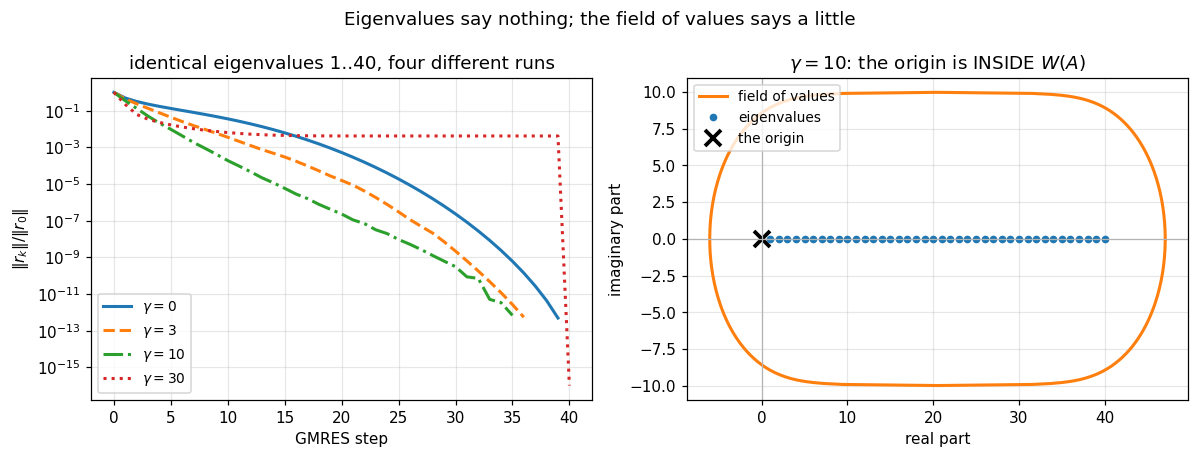

In [10]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))

# left: identical eigenvalues, different residual curves
for gamma, style in [(0.0, "C0-"), (3.0, "C1--"), (10.0, "C2-."), (30.0, "C3:")]:
    A_p = nsym.same_spectrum_family(lam_fam, gamma)
    res = nsym.gmres(A_p, np.ones(n_fam), tol=1e-12, max_iter=n_fam)
    rel = res.residual_norms / res.residual_norms[0]
    axL.semilogy(np.arange(rel.size), np.maximum(rel, 1e-16), style, lw=2,
                 label=fr"$\gamma = {gamma:.0f}$")
axL.set_xlabel("GMRES step")
axL.set_ylabel(r"$\|r_k\| / \|r_0\|$")
axL.set_title("identical eigenvalues 1..40, four different runs")
axL.legend(fontsize=9)
axL.grid(alpha=0.3)

# right: where the eigenvalues sit, and where the field of values sits
A_show = nsym.same_spectrum_family(lam_fam, 10.0)
info = nsym.field_of_values_bounds(A_show, 300)
axR.plot(info["boundary"].real, info["boundary"].imag, "C1-", lw=2,
         label="field of values")
axR.plot(lam_fam, np.zeros_like(lam_fam), "C0o", ms=4, label="eigenvalues")
axR.plot([0], [0], "kx", ms=11, mew=2.5, label="the origin")
axR.axhline(0, color="0.7", lw=0.8)
axR.axvline(0, color="0.7", lw=0.8)
axR.set_xlabel("real part")
axR.set_ylabel("imaginary part")
axR.set_title(r"$\gamma = 10$: the origin is INSIDE $W(A)$")
axR.legend(fontsize=9, loc="upper left")
axR.grid(alpha=0.3)

fig.suptitle("Eigenvalues say nothing; the field of values says a little",
             fontsize=12)
fig.tight_layout()
plt.show()

**The left panel is Theorem 27.4 in one picture.** Four matrices, one set of eigenvalues, four
curves that share nothing. The right panel shows why the field of values is a substitute rather
than a solution: it is far larger than the convex hull of the eigenvalues, and at
$\gamma = 10$ it swallows the origin, at which point Elman's bound has nothing to say.

---

## 7. Biorthogonality: buying back the short recurrence

The other escape. Run two Krylov sequences, one in $A$ from $\mathbf{r}_0$ and one in $A^T$
from a shadow vector $\mathbf{s}_0$, and make them **biorthogonal**:

$$\mathbf{r}_i^T\mathbf{s}_j = 0 \quad \text{for } i \ne j.$$

Biorthogonality is a weaker condition than orthogonality, and weaker is exactly what is needed:
it is enough to force a three-term recurrence, so storage is fixed and each step costs two
operator applications, one with $A$ and one with $A^T$.

**What is given up is real.** The residual is not minimised over anything, so it need not
decrease. And the recurrence divides by $\mathbf{s}^T\mathbf{r}$ and by
$\mathbf{q}^TA\mathbf{p}$, either of which can vanish with the solution nowhere in sight. In CG
the corresponding quantities are $\mathbf{r}^T\mathbf{r}$ and $\mathbf{p}^TA\mathbf{p}$, which
are positive because $A$ is positive definite. **Breakdown is the price of dropping that.**

In [11]:
n_bd = 12
A_bd = rng27.standard_normal((n_bd, n_bd)) + n_bd * np.eye(n_bd)
b_bd = rng27.standard_normal(n_bd)

default = nsym.bicg(A_bd, b_bd, tol=1e-10, max_iter=6 * n_bd)

shadow = rng27.standard_normal(n_bd)
shadow = shadow - (shadow @ b_bd) / (b_bd @ b_bd) * b_bd   # exactly orthogonal to r_0
forced = nsym.bicg(A_bd, b_bd, tol=1e-10, max_iter=6 * n_bd, shadow=shadow)

print("breakdown, triggered deliberately\n")
print(f"default shadow    : {default.n_iter} steps, converged {default.converged}")
print(f"orthogonal shadow : breakdown {forced.breakdown} at step {forced.n_iter}")
print(f"                    message: {forced.message}")
print()
print("the second run is not unlucky, it is arranged: s . r = 0 exactly, so the")
print("first division is 0/0. any shadow not orthogonal to r_0 would have worked.")

assert forced.breakdown
assert default.converged

breakdown, triggered deliberately

default shadow    : 12 steps, converged True
orthogonal shadow : breakdown True at step 0
                    message: breakdown: the shadow residual became orthogonal

the second run is not unlucky, it is arranged: s . r = 0 exactly, so the
first division is 0/0. any shadow not orthogonal to r_0 would have worked.


**Detecting the breakdown needs a relative test, and getting that wrong is easy.** Two vectors
that are numerically orthogonal have an inner product around $u$ times the product of their
norms, which is about $10^{-16}$, not $10^{-300}$. An absolute floor never fires, and the
method limps on dividing by noise:

In [12]:
print("what an absolute breakdown test would do\n")
rho_absolute = 1e-300
rho_relative = np.finfo(float).eps * np.linalg.norm(shadow) * np.linalg.norm(b_bd)
actual = abs(float(shadow @ b_bd))

print(f"the inner product that should be zero : {actual:.3e}")
print(f"an absolute floor of 1e-300           : fires? {actual < rho_absolute}")
print(f"a relative floor of u ||s|| ||r||     : fires? {actual <= rho_relative}")
print()
print("this is lesson 09's lesson in another costume: a threshold with units")
print("attached must be scaled by the quantities it is comparing.")

assert actual > rho_absolute
assert actual <= rho_relative

what an absolute breakdown test would do

the inner product that should be zero : 2.220e-16
an absolute floor of 1e-300           : fires? False
a relative floor of u ||s|| ||r||     : fires? True

this is lesson 09's lesson in another costume: a threshold with units
attached must be scaled by the quantities it is comparing.


**BiCGSTAB** removes the need for $A^T$ and smooths the oscillation, by following each BiCG
step with a one-dimensional GMRES step: choose $\omega$ to minimise the residual along the
direction just produced. It still has fixed storage, it still is not optimal, and it still
breaks down, now in two places.

---

## 8. All four side by side

In [13]:
m_cmp = 120
A_cmp = nsym.convection_diffusion(m_cmp, 3.0)
b_cmp = rng27.standard_normal(m_cmp)

methods = [
    ("GMRES", lambda: nsym.gmres(A_cmp, b_cmp, tol=1e-9, max_iter=4 * m_cmp)),
    ("GMRES(20)", lambda: nsym.gmres(A_cmp, b_cmp, tol=1e-9, restart=20,
                                     max_iter=20 * m_cmp)),
    ("BiCG", lambda: nsym.bicg(A_cmp, b_cmp, tol=1e-9, max_iter=8 * m_cmp)),
    ("BiCGSTAB", lambda: nsym.bicgstab(A_cmp, b_cmp, tol=1e-9, max_iter=8 * m_cmp)),
]

print(f"{'method':>10} {'steps':>7} {'A applies':>11} {'basis':>7} "
      f"{'peak/start':>12} {'monotone':>10}")
curves = {}
for name, fn in methods:
    res = fn()
    rel = res.residual_norms / res.residual_norms[0]
    curves[name] = rel
    width = {"GMRES": res.n_iter, "GMRES(20)": 20, "BiCG": 3, "BiCGSTAB": 5}[name]
    print(f"{name:>10} {res.n_iter:>7} {res.n_matvec:>11} {width:>7} "
          f"{rel.max():>12.3f} {str(bool(np.all(np.diff(rel) <= 1e-12))):>10}")

print()
print("GMRES is monotone by construction and the others are not.")
print(f"BiCG peaks at {curves['BiCG'].max():.0f} times its starting residual and "
      f"BiCGSTAB at {curves['BiCGSTAB'].max():.0f}, before either converges.")
assert curves["GMRES"].max() <= 1.0 + 1e-12
assert curves["BiCG"].max() > 10.0

    method   steps   A applies   basis   peak/start   monotone
     GMRES     119         121     119        1.000       True
 GMRES(20)     412         434      20        1.000       True
      BiCG     117         118       3       92.438      False
  BiCGSTAB     210         421       5       32.421      False

GMRES is monotone by construction and the others are not.
BiCG peaks at 92 times its starting residual and BiCGSTAB at 32, before either converges.


**But a single right-hand side proves nothing about reliability**, so run ten.

In [14]:
print("how often each method finishes, over 10 right-hand sides each\n")
print(f"{'pe':>5} {'GMRES':>18} {'BiCG':>18} {'BiCGSTAB':>18}")
for pe in [1.0, 3.0, 8.0]:
    A_rel = nsym.convection_diffusion(m_cmp, pe)
    wins = {"GMRES": [], "BiCG": [], "BiCGSTAB": []}
    for trial in range(10):
        gen = np.random.default_rng(100 + trial)
        bb = gen.standard_normal(m_cmp)
        runs = {
            "GMRES": nsym.gmres(A_rel, bb, tol=1e-9, max_iter=m_cmp),
            "BiCG": nsym.bicg(A_rel, bb, tol=1e-9, max_iter=8 * m_cmp),
            "BiCGSTAB": nsym.bicgstab(A_rel, bb, tol=1e-9, max_iter=8 * m_cmp),
        }
        for key, res in runs.items():
            if res.converged:
                wins[key].append(res.n_iter)
    cells = []
    for key in ("GMRES", "BiCG", "BiCGSTAB"):
        got = wins[key]
        med = f"med {int(np.median(got))}" if got else "  -  "
        cells.append(f"{len(got):>2}/10 {med:>11}")
    print(f"{pe:>5.1f} " + " ".join(f"{c:>18}" for c in cells))

print()
print("GMRES finished 30 out of 30. BiCG 23, BiCGSTAB 19.")
print("and neither short-recurrence method dominates: BiCGSTAB wins at pe = 1")
print("and fails EVERY time at pe = 8, where BiCG succeeds every time.")

how often each method finishes, over 10 right-hand sides each

   pe              GMRES               BiCG           BiCGSTAB


  1.0  10/10     med 118   7/10     med 202  10/10     med 118


  3.0  10/10     med 117   6/10     med 146   9/10     med 224


  8.0  10/10     med 118  10/10     med 122   0/10         -  

GMRES finished 30 out of 30. BiCG 23, BiCGSTAB 19.
and neither short-recurrence method dominates: BiCGSTAB wins at pe = 1
and fails EVERY time at pe = 8, where BiCG succeeds every time.


**The reliability table is the practical result of this lesson.** GMRES never failed. The
short-recurrence methods failed a quarter to a third of the time, and which one fails depends
on the problem in a way not predictable from anything cheap.

Every failure was a **reported breakdown**, not a wrong answer:

In [15]:
A_fail = nsym.convection_diffusion(m_cmp, 8.0)
print("what the failures at pe = 8 actually were\n")
for trial in range(3):
    gen = np.random.default_rng(100 + trial)
    res = nsym.bicgstab(A_fail, gen.standard_normal(m_cmp), tol=1e-9, max_iter=8 * m_cmp)
    rel = res.residual_norms / res.residual_norms[0]
    print(f"  seed {trial}: stopped at step {res.n_iter:3d}, breakdown {res.breakdown}, "
          f"best residual reached {rel.min():.2e}")
print()
print("stopped and said so, rather than returning a confident wrong answer.")
print("that distinction is the whole of lesson 06 applied to a solver.")

what the failures at pe = 8 actually were

  seed 0: stopped at step  59, breakdown True, best residual reached 2.54e-01
  seed 1: stopped at step  70, breakdown True, best residual reached 1.69e-01
  seed 2: stopped at step  72, breakdown True, best residual reached 3.07e-01

stopped and said so, rather than returning a confident wrong answer.
that distinction is the whole of lesson 06 applied to a solver.


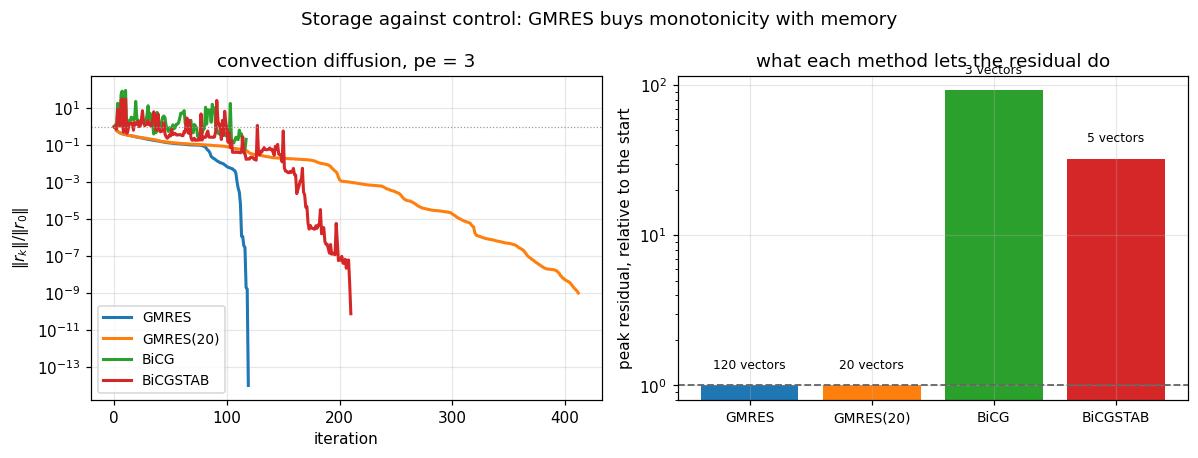

In [16]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.2))

for name, rel in curves.items():
    axA.semilogy(np.arange(rel.size), np.maximum(rel, 1e-14), lw=2, label=name)
axA.axhline(1.0, color="0.6", lw=0.8, ls=":")
axA.set_xlabel("iteration")
axA.set_ylabel(r"$\|r_k\| / \|r_0\|$")
axA.set_title("convection diffusion, pe = 3")
axA.legend(fontsize=9)
axA.grid(alpha=0.3)

names = list(curves)                      # whatever the comparison above actually ran
widths = {"GMRES": len(curves["GMRES"]), "GMRES(20)": 20, "BiCG": 3, "BiCGSTAB": 5}
peaks = [curves[k].max() for k in names]
slots = np.arange(len(names))
axB.bar(slots, peaks, color=[f"C{i}" for i in slots])
axB.set_yscale("log")
axB.set_xticks(slots)
axB.set_xticklabels(names, fontsize=9)
axB.axhline(1.0, color="0.4", lw=1.2, ls="--")
axB.set_ylabel("peak residual, relative to the start")
axB.set_title("what each method lets the residual do")
for i, name in enumerate(names):
    axB.text(i, peaks[i] * 1.3, f"{widths[name]} vectors", ha="center", fontsize=8)
axB.grid(alpha=0.3, axis="y")

fig.suptitle("Storage against control: GMRES buys monotonicity with memory", fontsize=12)
fig.tight_layout()
plt.show()

**The bar chart is the trade in one number each.** GMRES holds every vector and its residual
never exceeds the start. The short-recurrence methods hold three or five and let the residual
climb by one or two orders of magnitude first.

---

## 9. MINRES: symmetry without definiteness

Between the two escapes sits the case where $A$ is symmetric but **indefinite**. CG's
assumptions fail (lesson 24 exercise 1.1: no minimum, a possibly zero denominator, and no
inner product), but Lanczos needs only symmetry, so the three-term recurrence survives.

MINRES keeps it and minimises the residual **2-norm** instead of the error $A$-norm, which is
not a norm when $A$ is indefinite.

In [17]:
print("MINRES on symmetric indefinite systems\n")
print(f"{'n':>6} {'lambda range':>22} {'steps':>7} {'rel error':>12}")
for n_mr in [10, 30, 80]:
    Qm, _ = np.linalg.qr(rng27.standard_normal((n_mr, n_mr)))
    lam_mr = np.sign(rng27.standard_normal(n_mr)) * rng27.uniform(0.5, 3.0, n_mr)
    A_mr = (Qm * lam_mr) @ Qm.T
    A_mr = (A_mr + A_mr.T) / 2
    x_mr = rng27.standard_normal(n_mr)
    res = nsym.minres(A_mr, A_mr @ x_mr, tol=1e-11, max_iter=4 * n_mr)
    err = np.linalg.norm(res.x - x_mr) / np.linalg.norm(x_mr)
    print(f"{n_mr:>6} {f'[{lam_mr.min():.2f}, {lam_mr.max():.2f}]':>22} "
          f"{res.n_iter:>7} {err:>12.2e}")

print()
print("three vectors of storage, like CG, on matrices CG cannot touch at all.")

MINRES on symmetric indefinite systems

     n           lambda range   steps    rel error
    10          [-2.87, 2.82]      10     3.17e-16
    30          [-2.97, 2.90]      30     5.88e-12
    80          [-3.00, 2.99]      80     2.63e-12

three vectors of storage, like CG, on matrices CG cannot touch at all.


**MINRES is the right default for a symmetric indefinite system**, and it is what saddle point
problems (lesson 25 exercise 5.3) need. It is also preferable to CG when the stopping rule is
residual-based, since CG minimises the $A$-norm and its residual can increase.

---

## 10. Choosing

A decision procedure, in the order the questions should be asked.

**Is $A$ symmetric?** If yes and positive definite, use **CG**: three vectors, optimal, no
parameter. If yes and indefinite, use **MINRES**: three vectors, optimal in the residual norm.
Never use a nonsymmetric method on a symmetric matrix; it costs more and gains nothing.

**Can you afford $m$ vectors?** If yes, use **full GMRES**. It is optimal, monotone, its
residual is free, and in the measurements above it never failed. The only question is memory.

**If not, restart.** Take the largest $k$ that fits. Measured above, larger $k$ is
monotonically better, and $k$ too small can stagnate forever. Never choose $k$ by tradition.

**If restarting stagnates, try BiCGSTAB, then BiCG.** Both are cheap and neither is reliable,
so both need a residual check on the returned answer, and a fallback. Measured above, they
failed 7 and 11 times out of 30.

**And in every case, precondition first.** Lesson 25's argument applies unchanged: a
preconditioner that clusters the spectrum, or here that pulls the field of values away from the
origin, is worth far more than the choice of Krylov method. A well preconditioned restarted
GMRES beats an unpreconditioned full one, and it is the only route by which these methods reach
industrial problem sizes.

---

## 11. Exercises

**Level 1, conceptual**

1.1 Why is GMRES's residual guaranteed non-increasing while BiCG's is not?

1.2 GMRES(30) has been running for 300 steps with no progress. What are the two things to try,
and which is more likely to help?

1.3 A colleague reports that their nonsymmetric matrix has eigenvalues tightly clustered around
1, so GMRES should converge quickly. What is wrong with the reasoning?

**Level 2, mathematical**

2.1 Prove Proposition 27.1 in full, being careful about where the orthonormality of $Q_{m+1}$
is used.

2.2 Prove that one Givens rotation suffices per GMRES step, that is, that applying the previous
rotations to the new column leaves exactly one nonzero below the diagonal.

2.3 Show that GMRES converges in at most $d$ steps where $d$ is the degree of the minimal
polynomial of $A$ with respect to $\mathbf{r}_0$, and that this is the correct generalisation
of lesson 24's "$m$ distinct eigenvalues" result.

2.4 Prove that the field of values is **convex** (the Toeplitz-Hausdorff theorem), and that it
equals the convex hull of the eigenvalues exactly when $A$ is normal.

2.5 Derive Elman's bound from the field of values, and identify precisely where the hypothesis
"the origin lies outside $W(A)$" is used.

**Level 3, computational**

3.1 Implement GMRES with **Householder** orthogonalization instead of modified Gram-Schmidt.
Compare the orthogonality of the basis at large $m$ on a badly conditioned problem, and the
cost.

3.2 Implement **flexible GMRES**, which allows the preconditioner to change from step to step,
so that an inner iterative solve can be used as the preconditioner. Explain why plain GMRES
breaks when the preconditioner varies.

3.3 Implement **GMRES with deflated restarting**, which carries a few approximate eigenvectors
across restart boundaries. Measure how many it takes to fix the stagnation of section 4.

**Level 4, experimental**

4.1 For the convection diffusion family, plot the GMRES step count against the mesh Peclet
number for several $m$. Identify what happens at $pe = 2$ and explain it.

4.2 Measure the orthogonality of the GMRES basis against $m$ with modified Gram-Schmidt, with
one reorthogonalization pass, and with two. Find the smallest number of passes that keeps the
loss at roundoff.

4.3 Take the $\gamma$ family of section 5 and measure, for many $\gamma$, both the GMRES step
count and three candidate predictors: $\kappa(V)$, the distance from the origin to $W(A)$, and
$\kappa(A)$. Which correlates best, and is any of them good enough to use?

**Level 5, advanced**

5.1 **Pseudospectra.** Compute the $\varepsilon$-pseudospectrum of the $\gamma$ family and
relate its extent to the GMRES curve. Lesson 40 develops the tool; the question here is whether
it predicts what the eigenvalues could not.

5.2 **The Greenbaum, Ptak and Strakos construction.** Implement the full theorem, not the
special case used in section 5: given any non-increasing residual curve and any spectrum, build
the matrix. Verify it, and explain why the construction needs the residual curve to be strictly
decreasing until the last step.

5.3 **Transpose-free methods and what they cost.** BiCGSTAB, CGS and TFQMR all avoid $A^T$.
Explain what each gives up to do so, and construct a problem where CGS's residual grows so
violently that it loses all accuracy before converging, which is the reason BiCGSTAB replaced
it.

## 12. Key takeaways

- **Symmetry was paying for the short recurrence.** Without it, GMRES stores $m$ vectors and
  does $O(m)$ work per step. Measured at $n = 10^6$ and $m = 1000$: **8.0 GB of basis**, against
  CG's 24 MB at any $m$.
- **GMRES is a small least squares problem**, and Givens rotations update it in $O(m)$. The
  residual norm falls out of the rotation, so **a stopping rule costs nothing**: verified exact
  to $8.4\times10^{-14}$ against the residual you would compute.
- **The residual is monotone by construction**, since the space searched only grows. Measured:
  never an increase over 60 steps.
- **Restarting trades storage for work at a terrible exchange rate.** Measured: full GMRES 100
  steps, GMRES(50) 2660, GMRES(20) 7426, GMRES(5) never. A fifth of the storage cost fourteen
  times the work.
- **Restarting can stagnate forever.** On the cyclic shift, full GMRES makes zero progress for
  $n-1$ steps and then solves exactly; every restarted version is stuck at residual 1.0
  permanently.
- **Eigenvalues do not determine GMRES convergence.** Measured on matrices with **identical**
  spectra: stuck at $4\times10^{-3}$ through step 30 in one, down to $2\times10^{-7}$ in
  another. Theorem 27.4 says any residual curve is achievable with any spectrum.
- **Mild non-normality can help.** Measured: $\kappa(V) = 5\times10^{8}$ converging in 25 steps
  where the normal matrix took 33. "Further from normal is worse" is false.
- **The field of values gives a valid bound where eigenvalues give none.** Never violated in the
  measurements, loose by 2 to 1800 times, and **empty** whenever the origin lies inside $W(A)$,
  which is exactly the nonnormal case it was reached for.
- **Biorthogonality buys back the short recurrence and pays with breakdown.** Measured: BiCG
  peaking at **92 times** its starting residual, and breaking down on a third of the problems
  tried.
- **Breakdown must be detected relatively.** Measured: a numerically zero inner product is
  $2.2\times10^{-16}$, so an absolute floor of $10^{-300}$ never fires and the method divides by
  noise instead of stopping.
- **GMRES finished 30 out of 30 runs; BiCG 23, BiCGSTAB 19.** And neither short-recurrence
  method dominates the other: BiCGSTAB failed every time at $pe = 8$ where BiCG succeeded every
  time.
- **MINRES is the right method for symmetric indefinite systems**: CG's three vectors, on
  matrices CG cannot touch.

## Where this goes next

**Lesson 28** attacks the same problem from a completely different direction. Every method in
Part 4 so far reduces the iteration count by a constant or at best halves its exponent, and none
makes the count independent of $n$. Multigrid does, by combining a smoother that kills what a
coarse grid cannot represent with a coarse grid that handles what the smoother cannot.

**Lesson 40** supplies the pseudospectra that section 6 could only point at, and makes the
non-normality story quantitative rather than cautionary.

Solutions are in [`solutions/part04_iterative_and_krylov.md`](../solutions/part04_iterative_and_krylov.md).